
# 01. Performance overview of predictive-model exploration

This notebook provides the first analysis layer over the predictive-model exploration runs. Its main goal is to answer three broad questions:

1. What is the global distribution of model performance across all explored configurations?
2. Which configurations appear at the top when performance is summarized in a robust way?
3. How stable are the results across validation seeds and validation strategies?

The notebook is intentionally focused on **overview and ranking**, rather than on factor-level effects or interactions. Those will be analyzed in subsequent notebooks.


In [1]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_context("talk")


plt.rcParams["figure.dpi"] = 140

In [2]:
def find_repo_root(start: Path | None = None, repo_name: str = "hypercholesterolemia_classifiers") -> Path:
    candidates = []
    if start is not None:
        candidates.append(start.resolve())
    candidates.extend([
        Path.cwd().resolve(),
        Path("/home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers/"),
    ])
    for candidate in candidates:
        if candidate.name == repo_name and candidate.exists():
            return candidate
        for parent in [candidate, *candidate.parents]:
            if parent.name == repo_name and parent.exists():
                return parent
    raise FileNotFoundError("Could not locate the repository root.")

REPO_ROOT = find_repo_root()
RUNS_ROOT = REPO_ROOT / "notebooks" / "modelling" / "runs"
CONFIGS_ROOT = REPO_ROOT / "configs" / "variants"
ANALYSIS_DIR = REPO_ROOT / "notebooks" / "modelling" / "analysis_tables"
FIGURES_DIR = REPO_ROOT / "notebooks" / "modelling" / "analysis_figures" / "01_performance_overview"

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig: plt.Figure, filename: str, dpi: int = 300) -> Path:
    out_path = FIGURES_DIR / filename
    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    return out_path

print("Repository root:", REPO_ROOT)
print("Runs root:", RUNS_ROOT)
print("Configs root:", CONFIGS_ROOT)
print("Analysis tables:", ANALYSIS_DIR)
print("Figures dir:", FIGURES_DIR)

Repository root: /home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers
Runs root: /home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers/notebooks/modelling/runs
Configs root: /home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers/configs/variants
Analysis tables: /home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers/notebooks/modelling/analysis_tables
Figures dir: /home/dmedina/Desktop/colabs/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/01_performance_overview


In [3]:

METRIC_COLUMNS = [
    "roc_auc",
    "pr_auc",
    "mcc",
    "brier",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
]

COUNT_COLUMNS = ["tn", "fp", "fn", "tp", "n_train", "n_test", "pos_rate_test"]

GROUP_ID_COLUMNS = [
    "dataset_variant",
    "config_name",
    "run_id",
    "combo_id",
    "val_strategy",
    "seed",
    "threshold",
    "model_key",
    "model_class",
    "imputer",
    "scaler",
    "pca",
    "pca_params",
    "resampling",
    "resampling_params",
    "model_params",
    "task_id",
]

def parse_result_path(path: Path) -> dict:
    rel = path.relative_to(RUNS_ROOT)
    task_match = re.search(r"results_task(\d+)_part(\d+)\.parquet$", path.name)
    return {
        "dataset_variant": rel.parts[0],
        "config_name": rel.parts[1],
        "run_id": rel.parts[2].replace("run_", ""),
        "task_id": int(task_match.group(1)) if task_match else None,
        "part_id": int(task_match.group(2)) if task_match else None,
        "file_path": str(path),
    }

def load_metadata_index() -> pd.DataFrame:
    rows = []
    for meta_path in RUNS_ROOT.glob("*/*/run_*/*.json"):
        if not meta_path.name.startswith("run_metadata_task"):
            continue
        rel = meta_path.relative_to(RUNS_ROOT)
        dataset_variant, config_name, run_folder = rel.parts[:3]
        task_match = re.search(r"run_metadata_task(\d+)\.json$", meta_path.name)
        task_id = int(task_match.group(1)) if task_match else None
        with open(meta_path, "r", encoding="utf-8") as handle:
            data = json.load(handle)
        rows.append({
            "dataset_variant": dataset_variant,
            "config_name": config_name,
            "run_id": run_folder.replace("run_", ""),
            "task_id": task_id,
            "n_rows_dataset": data.get("n_rows"),
            "pos_rate_dataset": data.get("pos_rate"),
            "target": data.get("target"),
            "n_predictors": data.get("n_predictors"),
            "n_combos_total": data.get("n_combos_total"),
            "n_combos_shard": data.get("n_combos_shard"),
            "data_path": data.get("data_path"),
            "config_path": data.get("config_path"),
        })
    meta = pd.DataFrame(rows)
    if not meta.empty:
        meta = meta.sort_values(["dataset_variant", "config_name", "run_id", "task_id"]).reset_index(drop=True)
    return meta

metadata_index = load_metadata_index()
metadata_index.head()


,dataset_variant,config_name,run_id,task_id,n_rows_dataset,pos_rate_dataset,target,n_predictors,n_combos_total,n_combos_shard,data_path,config_path
0,IMPUTED,config_kfold,20260202_032849,0,160,0.275,MSPH,11,511720,25586,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
1,IMPUTED,config_kfold,20260202_032849,4,160,0.275,MSPH,11,511720,25586,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
2,IMPUTED,config_kfold,20260202_032849,5,160,0.275,MSPH,11,511720,25586,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
3,IMPUTED,config_kfold,20260202_032849,6,160,0.275,MSPH,11,511720,25586,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
4,IMPUTED,config_kfold,20260202_032849,7,160,0.275,MSPH,11,511720,25586,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...


In [4]:

result_files = sorted(RUNS_ROOT.glob("*/*/run_*/*.parquet"))
print(f"Detected {len(result_files):,} parquet result files.")

files_index = pd.DataFrame(parse_result_path(path) for path in result_files)
files_index.head()


Detected 7,172 parquet result files.


,dataset_variant,config_name,run_id,task_id,part_id,file_path
0,IMPUTED,config_kfold,20260202_032849,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...
1,IMPUTED,config_kfold,20260202_032849,0,1,/home/dmedina/Desktop/colabs/hypercholesterole...
2,IMPUTED,config_kfold,20260202_032849,0,2,/home/dmedina/Desktop/colabs/hypercholesterole...
3,IMPUTED,config_kfold,20260202_032849,0,3,/home/dmedina/Desktop/colabs/hypercholesterole...
4,IMPUTED,config_kfold,20260202_032849,0,4,/home/dmedina/Desktop/colabs/hypercholesterole...


In [5]:
def read_result_file(path: Path, columns: list[str] | None = None) -> pd.DataFrame:
    parquet_file = pq.ParquetFile(path)
    available_columns = parquet_file.schema.names

    if columns is not None:
        requested_columns = columns
        columns = [col for col in columns if col in available_columns]
        missing = sorted(set(requested_columns) - set(columns))
        if missing:
            print(f"[warn] {path.name}: skipping missing columns {missing}")

    table = parquet_file.read(columns=columns)
    df = table.to_pandas()
    meta = parse_result_path(path)
    for key, value in meta.items():
        df[key] = value
    return df

sample_df = read_result_file(
    result_files[0],
    columns=GROUP_ID_COLUMNS[3:] + METRIC_COLUMNS + COUNT_COLUMNS
)
print(sample_df.shape)
sample_df.head()

[warn] results_task0000_part0000.parquet: skipping missing columns ['task_id']
(2000, 35)


,combo_id,val_strategy,seed,threshold,model_key,model_class,imputer,scaler,pca,pca_params,resampling,resampling_params,model_params,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,n_train,n_test,pos_rate_test,dataset_variant,config_name,run_id,task_id,part_id,file_path
0,1,kfold,478163327,0.5,LogisticRegression,LogisticRegression,none,none,off,{},none,{},"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",0.855072,0.694711,0.275713,0.151991,0.75000,0.589372,0.666667,0.222222,0.333333,22,1,7,2,128,32,0.28125,IMPUTED,config_kfold,20260202_032849,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...
1,1,kfold,478163327,0.5,LogisticRegression,LogisticRegression,none,none,off,{},none,{},"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",0.869565,0.850644,0.690821,0.110974,0.87500,0.845411,0.777778,0.777778,0.777778,21,2,2,7,128,32,0.28125,IMPUTED,config_kfold,20260202_032849,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...
2,1,kfold,478163327,0.5,LogisticRegression,LogisticRegression,none,none,off,{},none,{},"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",0.850242,0.562440,0.477973,0.155929,0.78125,0.746377,0.600000,0.666667,0.631579,19,4,3,6,128,32,0.28125,IMPUTED,config_kfold,20260202_032849,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...
3,1,kfold,478163327,0.5,LogisticRegression,LogisticRegression,none,none,off,{},none,{},"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",0.830918,0.742845,0.394055,0.139052,0.78125,0.644928,0.750000,0.333333,0.461538,22,1,6,3,128,32,0.28125,IMPUTED,config_kfold,20260202_032849,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...
4,1,kfold,478163327,0.5,LogisticRegression,LogisticRegression,none,none,off,{},none,{},"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",0.609375,0.446627,0.218218,0.200668,0.75000,0.583333,0.500000,0.250000,0.333333,22,2,6,2,128,32,0.25000,IMPUTED,config_kfold,20260202_032849,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...


## 1. Build compact analysis tables

The raw results are stored across many parquet files and each row corresponds to a fold- or split-level evaluation for one configuration. For the overview notebook, the most useful table is a compact configuration-level summary aggregated across folds or splits within each seed.

A special case is leave-one-out (LOO) validation. Because each evaluation unit contains a single test sample, several probabilistic metrics such as ROC-AUC, PR-AUC, and Brier score are not meaningfully defined at the unit level. To make LOO comparable to the other validation strategies, the notebook reconstructs classical classification metrics by summing the confusion-matrix counts across all individual LOO predictions within each configuration and seed, and then recomputing accuracy, balanced accuracy, precision, recall, F1, and MCC from the aggregated counts. Probabilistic metrics remain unavailable for LOO and are therefore kept as missing values.

In [ ]:

ANALYSIS_COLUMNS = [
    "run_id",
    "combo_id",
    "split_id",
    "threshold",
    "val_strategy",
    "seed",
    "model_key",
    "model_class",
    "model_params",
    "imputer",
    "scaler",
    "pca",
    "pca_params",
    "resampling",
    "resampling_params",
    "n_train",
    "n_test",
    "pos_rate_test",
    *METRIC_COLUMNS,
    *COUNT_COLUMNS[:4],
]

raw_frames = []
for idx, path in enumerate(result_files, start=1):
    df_part = read_result_file(path, columns=ANALYSIS_COLUMNS)
    raw_frames.append(df_part)
    if idx % 250 == 0 or idx == len(result_files):
        print(f"Loaded {idx:,}/{len(result_files):,} files")

results_raw = pd.concat(raw_frames, ignore_index=True)
del raw_frames

results_raw = results_raw.merge(
    metadata_index,
    how="left",
    on=["dataset_variant", "config_name", "run_id", "task_id"],
    validate="many_to_one",
)

print(results_raw.shape)
results_raw.head()


Loaded 250/7,172 files
Loaded 500/7,172 files
Loaded 750/7,172 files
Loaded 1,000/7,172 files
Loaded 1,250/7,172 files
Loaded 1,500/7,172 files
Loaded 1,750/7,172 files
Loaded 2,000/7,172 files
Loaded 2,250/7,172 files
Loaded 2,500/7,172 files
Loaded 2,750/7,172 files
Loaded 3,000/7,172 files
Loaded 3,250/7,172 files
Loaded 3,500/7,172 files
Loaded 3,750/7,172 files
Loaded 4,000/7,172 files
Loaded 4,250/7,172 files
Loaded 4,500/7,172 files
Loaded 4,750/7,172 files
Loaded 5,000/7,172 files
Loaded 5,250/7,172 files
Loaded 5,500/7,172 files
Loaded 5,750/7,172 files
Loaded 6,000/7,172 files
Loaded 6,250/7,172 files
Loaded 6,500/7,172 files
Loaded 6,750/7,172 files
Loaded 7,000/7,172 files
Loaded 7,172/7,172 files
(14229119, 44)


,run_id,combo_id,split_id,threshold,val_strategy,seed,model_key,model_class,model_params,imputer,scaler,pca,pca_params,resampling,resampling_params,n_train,n_test,pos_rate_test,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,dataset_variant,config_name,task_id,part_id,file_path,n_rows_dataset,pos_rate_dataset,target,n_predictors,n_combos_total,n_combos_shard,data_path,config_path
0,20260202_032849,1,kfold_5_seed478163327_01,0.5,kfold,478163327,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},128,32,0.28125,0.855072,0.694711,0.275713,0.151991,0.75000,0.589372,0.666667,0.222222,0.333333,22,1,7,2,IMPUTED,config_kfold,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...,160.0,0.275,MSPH,11.0,511720.0,25586.0,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
1,20260202_032849,1,kfold_5_seed478163327_02,0.5,kfold,478163327,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},128,32,0.28125,0.869565,0.850644,0.690821,0.110974,0.87500,0.845411,0.777778,0.777778,0.777778,21,2,2,7,IMPUTED,config_kfold,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...,160.0,0.275,MSPH,11.0,511720.0,25586.0,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
2,20260202_032849,1,kfold_5_seed478163327_03,0.5,kfold,478163327,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},128,32,0.28125,0.850242,0.562440,0.477973,0.155929,0.78125,0.746377,0.600000,0.666667,0.631579,19,4,3,6,IMPUTED,config_kfold,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...,160.0,0.275,MSPH,11.0,511720.0,25586.0,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
3,20260202_032849,1,kfold_5_seed478163327_04,0.5,kfold,478163327,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},128,32,0.28125,0.830918,0.742845,0.394055,0.139052,0.78125,0.644928,0.750000,0.333333,0.461538,22,1,6,3,IMPUTED,config_kfold,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...,160.0,0.275,MSPH,11.0,511720.0,25586.0,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...
4,20260202_032849,1,kfold_5_seed478163327_05,0.5,kfold,478163327,LogisticRegression,LogisticRegression,"{""C"": 0.1, ""class_weight"": null, ""penalty"": ""l2""}",none,none,off,{},none,{},128,32,0.25000,0.609375,0.446627,0.218218,0.200668,0.75000,0.583333,0.500000,0.250000,0.333333,22,2,6,2,IMPUTED,config_kfold,0,0,/home/dmedina/Desktop/colabs/hypercholesterole...,160.0,0.275,MSPH,11.0,511720.0,25586.0,/home/dmedina/hypercholesterolemia_classifiers...,/home/dmedina/hypercholesterolemia_classifiers...


: 

In [ ]:
seed_group_cols = [
    "dataset_variant",
    "config_name",
    "run_id",
    "combo_id",
    "val_strategy",
    "seed",
    "threshold",
    "model_key",
    "model_class",
    "model_params",
    "imputer",
    "scaler",
    "pca",
    "pca_params",
    "resampling",
    "resampling_params",
]

def compute_classical_metrics_from_counts(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    tp = out["tp"].astype(float)
    tn = out["tn"].astype(float)
    fp = out["fp"].astype(float)
    fn = out["fn"].astype(float)

    out["accuracy"] = (tp + tn) / (tp + tn + fp + fn).replace(0, np.nan)
    tpr = tp / (tp + fn).replace(0, np.nan)
    tnr = tn / (tn + fp).replace(0, np.nan)
    out["balanced_accuracy"] = (tpr + tnr) / 2.0
    out["precision"] = tp / (tp + fp).replace(0, np.nan)
    out["recall"] = tpr
    out["f1"] = (2 * tp) / (2 * tp + fp + fn).replace(0, np.nan)

    mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    out["mcc"] = ((tp * tn) - (fp * fn)) / pd.Series(mcc_den).replace(0, np.nan)
    return out

mean_metric_agg = {metric: "mean" for metric in METRIC_COLUMNS}
mean_metric_agg.update({
    "n_train": "mean",
    "n_test": "mean",
    "pos_rate_test": "mean",
    "split_id": "nunique",
    "tn": "sum",
    "fp": "sum",
    "fn": "sum",
    "tp": "sum",
})

results_seed_level_nonloo = (
    results_raw
    .query("config_name != 'config_loo'")
    .groupby(seed_group_cols, dropna=False, as_index=False)
    .agg(mean_metric_agg)
    .rename(columns={"split_id": "n_evaluation_units"})
)

results_seed_level_loo = (
    results_raw
    .query("config_name == 'config_loo'")
    .groupby(seed_group_cols, dropna=False, as_index=False)
    .agg({
        "tn": "sum",
        "fp": "sum",
        "fn": "sum",
        "tp": "sum",
        "n_train": "mean",
        "n_test": "sum",
        "pos_rate_test": "mean",
        "split_id": "nunique",
    })
    .rename(columns={"split_id": "n_evaluation_units"})
)

if not results_seed_level_loo.empty:
    results_seed_level_loo = compute_classical_metrics_from_counts(results_seed_level_loo)
    results_seed_level_loo["roc_auc"] = np.nan
    results_seed_level_loo["pr_auc"] = np.nan
    results_seed_level_loo["brier"] = np.nan
    results_seed_level_loo["loo_metric_source"] = "reconstructed_from_confusion_counts"
else:
    results_seed_level_loo["loo_metric_source"] = pd.Series(dtype="object")

results_seed_level_nonloo["loo_metric_source"] = "reported_fold_mean"

results_seed_level = pd.concat(
    [results_seed_level_nonloo, results_seed_level_loo],
    ignore_index=True,
    sort=False,
)

preferred_cols = seed_group_cols + [
    "n_evaluation_units",
    "n_train",
    "n_test",
    "pos_rate_test",
    "tn",
    "fp",
    "fn",
    "tp",
    *METRIC_COLUMNS,
    "loo_metric_source",
]
results_seed_level = results_seed_level.loc[:, [c for c in preferred_cols if c in results_seed_level.columns]]

print(results_seed_level.shape)
results_seed_level.head()

In [ ]:

run_summary = (
    results_raw[["dataset_variant", "config_name", "run_id", "task_id", "combo_id"]]
    .drop_duplicates()
    .groupby(["dataset_variant", "config_name", "run_id"], as_index=False)
    .agg(
        n_tasks=("task_id", "nunique"),
        n_unique_combos=("combo_id", "nunique"),
    )
    .merge(
        metadata_index.groupby(["dataset_variant", "config_name", "run_id"], as_index=False).agg(
            n_rows_dataset=("n_rows_dataset", "max"),
            pos_rate_dataset=("pos_rate_dataset", "max"),
            n_predictors=("n_predictors", "max"),
            target=("target", "first"),
        ),
        on=["dataset_variant", "config_name", "run_id"],
        how="left",
    )
    .sort_values(["dataset_variant", "config_name", "run_id"])
)

run_summary


,dataset_variant,config_name,run_id,n_tasks,n_unique_combos,n_rows_dataset,pos_rate_dataset,n_predictors,target
0,IMPUTED,config_kfold,20260202_032849,20,452604,160.0,0.275000,11.0,MSPH
1,IMPUTED,config_loo,20260202_100003,1,1280,160.0,0.275000,11.0,MSPH
2,IMPUTED,config_loo,20260202_100011,1,838,NaN,NaN,NaN,NaN
3,IMPUTED,config_loo,20260202_100103,1,1280,160.0,0.275000,11.0,MSPH
4,IMPUTED,config_loo,20260202_100116,1,763,NaN,NaN,NaN,NaN
5,IMPUTED,config_loo,20260202_100237,1,1280,160.0,0.275000,11.0,MSPH
6,IMPUTED,config_loo,20260202_100253,1,1280,160.0,0.275000,11.0,MSPH
7,IMPUTED,config_loo,20260202_100319,1,763,NaN,NaN,NaN,NaN
8,IMPUTED,config_loo,20260202_100431,1,713,NaN,NaN,NaN,NaN
9,IMPUTED,config_loo,20260202_100858,1,863,NaN,NaN,NaN,NaN


## 2. Global distribution of performance metrics

This first view answers a simple question: what does the explored performance landscape look like overall? We examine the seed-level summaries because they are less noisy and better reflect configuration-level behavior. For cross-strategy comparisons that include LOO, the notebook emphasizes classical classification metrics reconstructed from confusion counts when needed. Probabilistic metrics are still shown for the validation strategies in which they are defined.

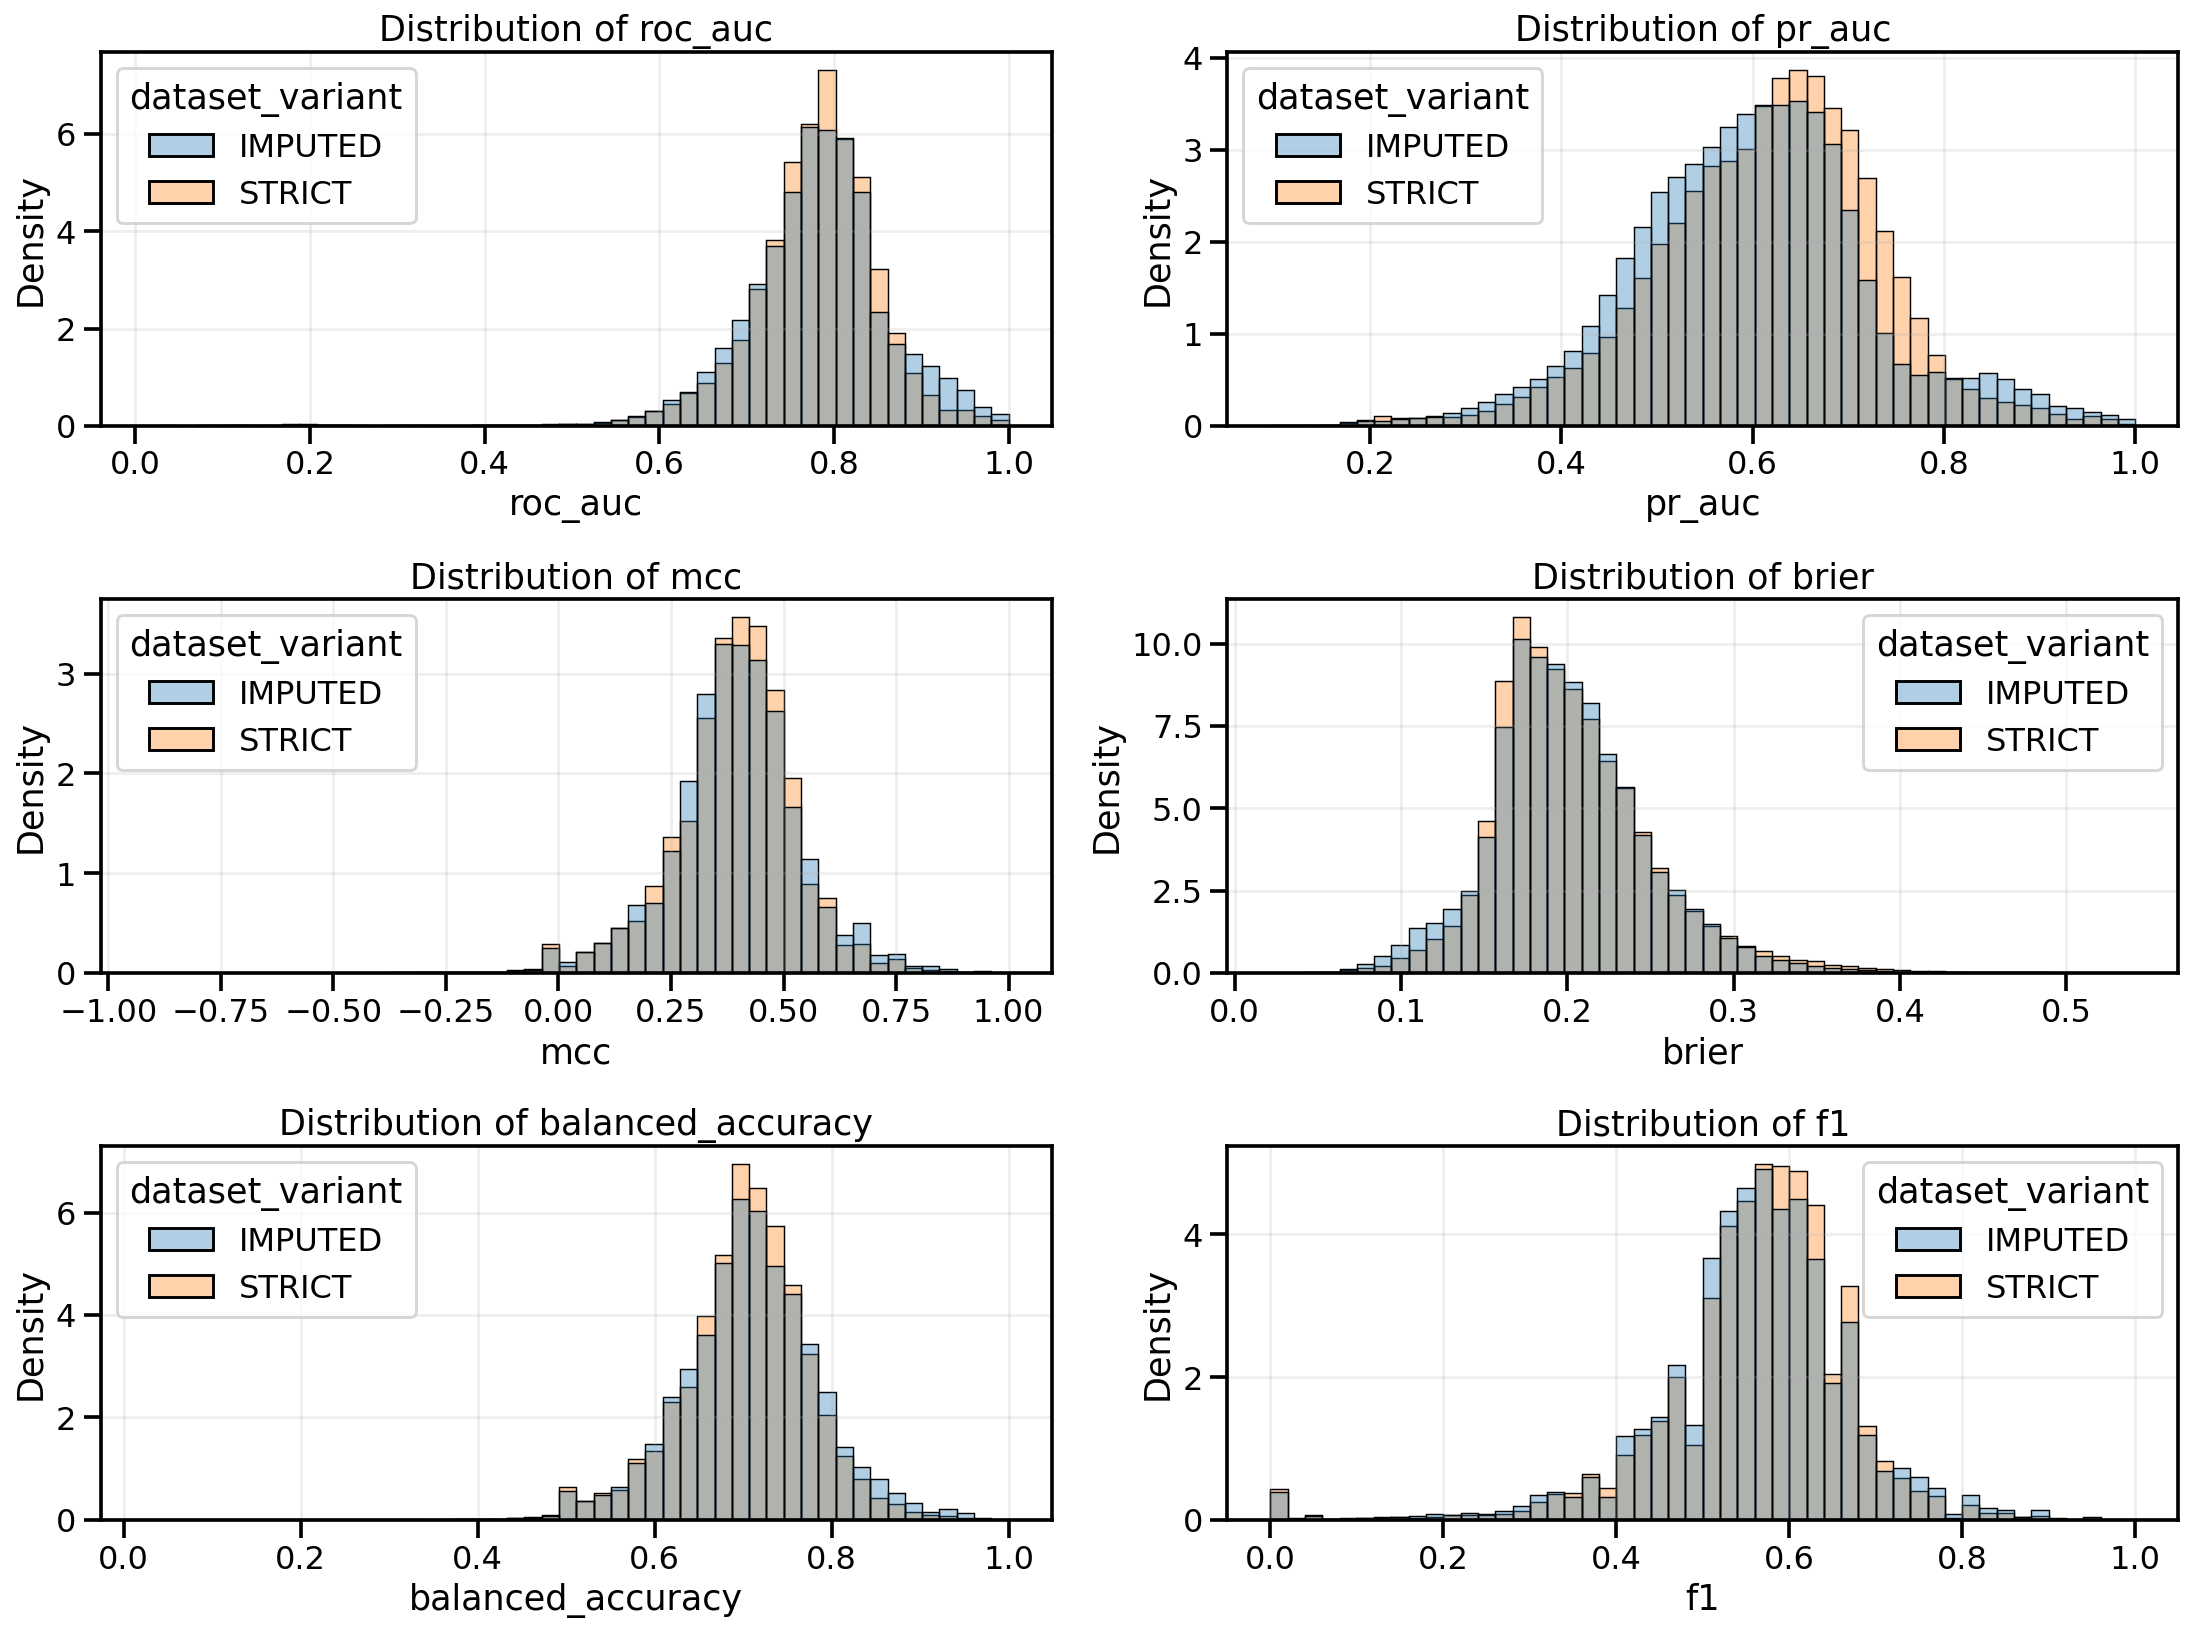

In [ ]:
def plot_metric_distributions(
    df: pd.DataFrame,
    metrics: list[str],
    by: str = "dataset_variant",
    bins: int = 40,
    figsize: tuple[int, int] = (16, 12),
):
    fig, axes = plt.subplots(math.ceil(len(metrics) / 2), 2, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, metric in zip(axes, metrics):
        plot_df = df.loc[df[metric].notna()].copy()
        sns.histplot(
            data=plot_df,
            x=metric,
            hue=by,
            bins=bins,
            stat="density",
            common_norm=False,
            alpha=0.35,
            ax=ax,
        )
        ax.set_title(f"Distribution of {metric}")
        ax.grid(alpha=0.2)
    for ax in axes[len(metrics):]:
        ax.axis("off")
    plt.tight_layout()
    return fig

fig = plot_metric_distributions(
    results_seed_level,
    metrics=["roc_auc", "pr_auc", "mcc", "brier", "balanced_accuracy", "f1"],
    by="dataset_variant",
    bins=50,
)
save_figure(fig, "metric_distributions_seed_level.png")
plt.show()

,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1
config_name,,,,,,,,,
config_kfold,944152,944152,944152,944152,944152,944152,944152,944152,944152
config_loo,0,0,39610,0,39789,39789,39610,39789,39789
config_random80,504927,504927,504927,504927,504927,504927,504927,504927,504927
config_strat80,511720,511720,511720,511720,511720,511720,511720,511720,511720


,roc_auc,pr_auc,mcc,brier,accuracy,balanced_accuracy,precision,recall,f1
config_name,,,,,,,,,
config_kfold,1.0,1.0,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0
config_loo,0.0,0.0,0.995501,0.0,1.0,1.0,0.995501,1.0,1.0
config_random80,1.0,1.0,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0
config_strat80,1.0,1.0,1.000000,1.0,1.0,1.0,1.000000,1.0,1.0


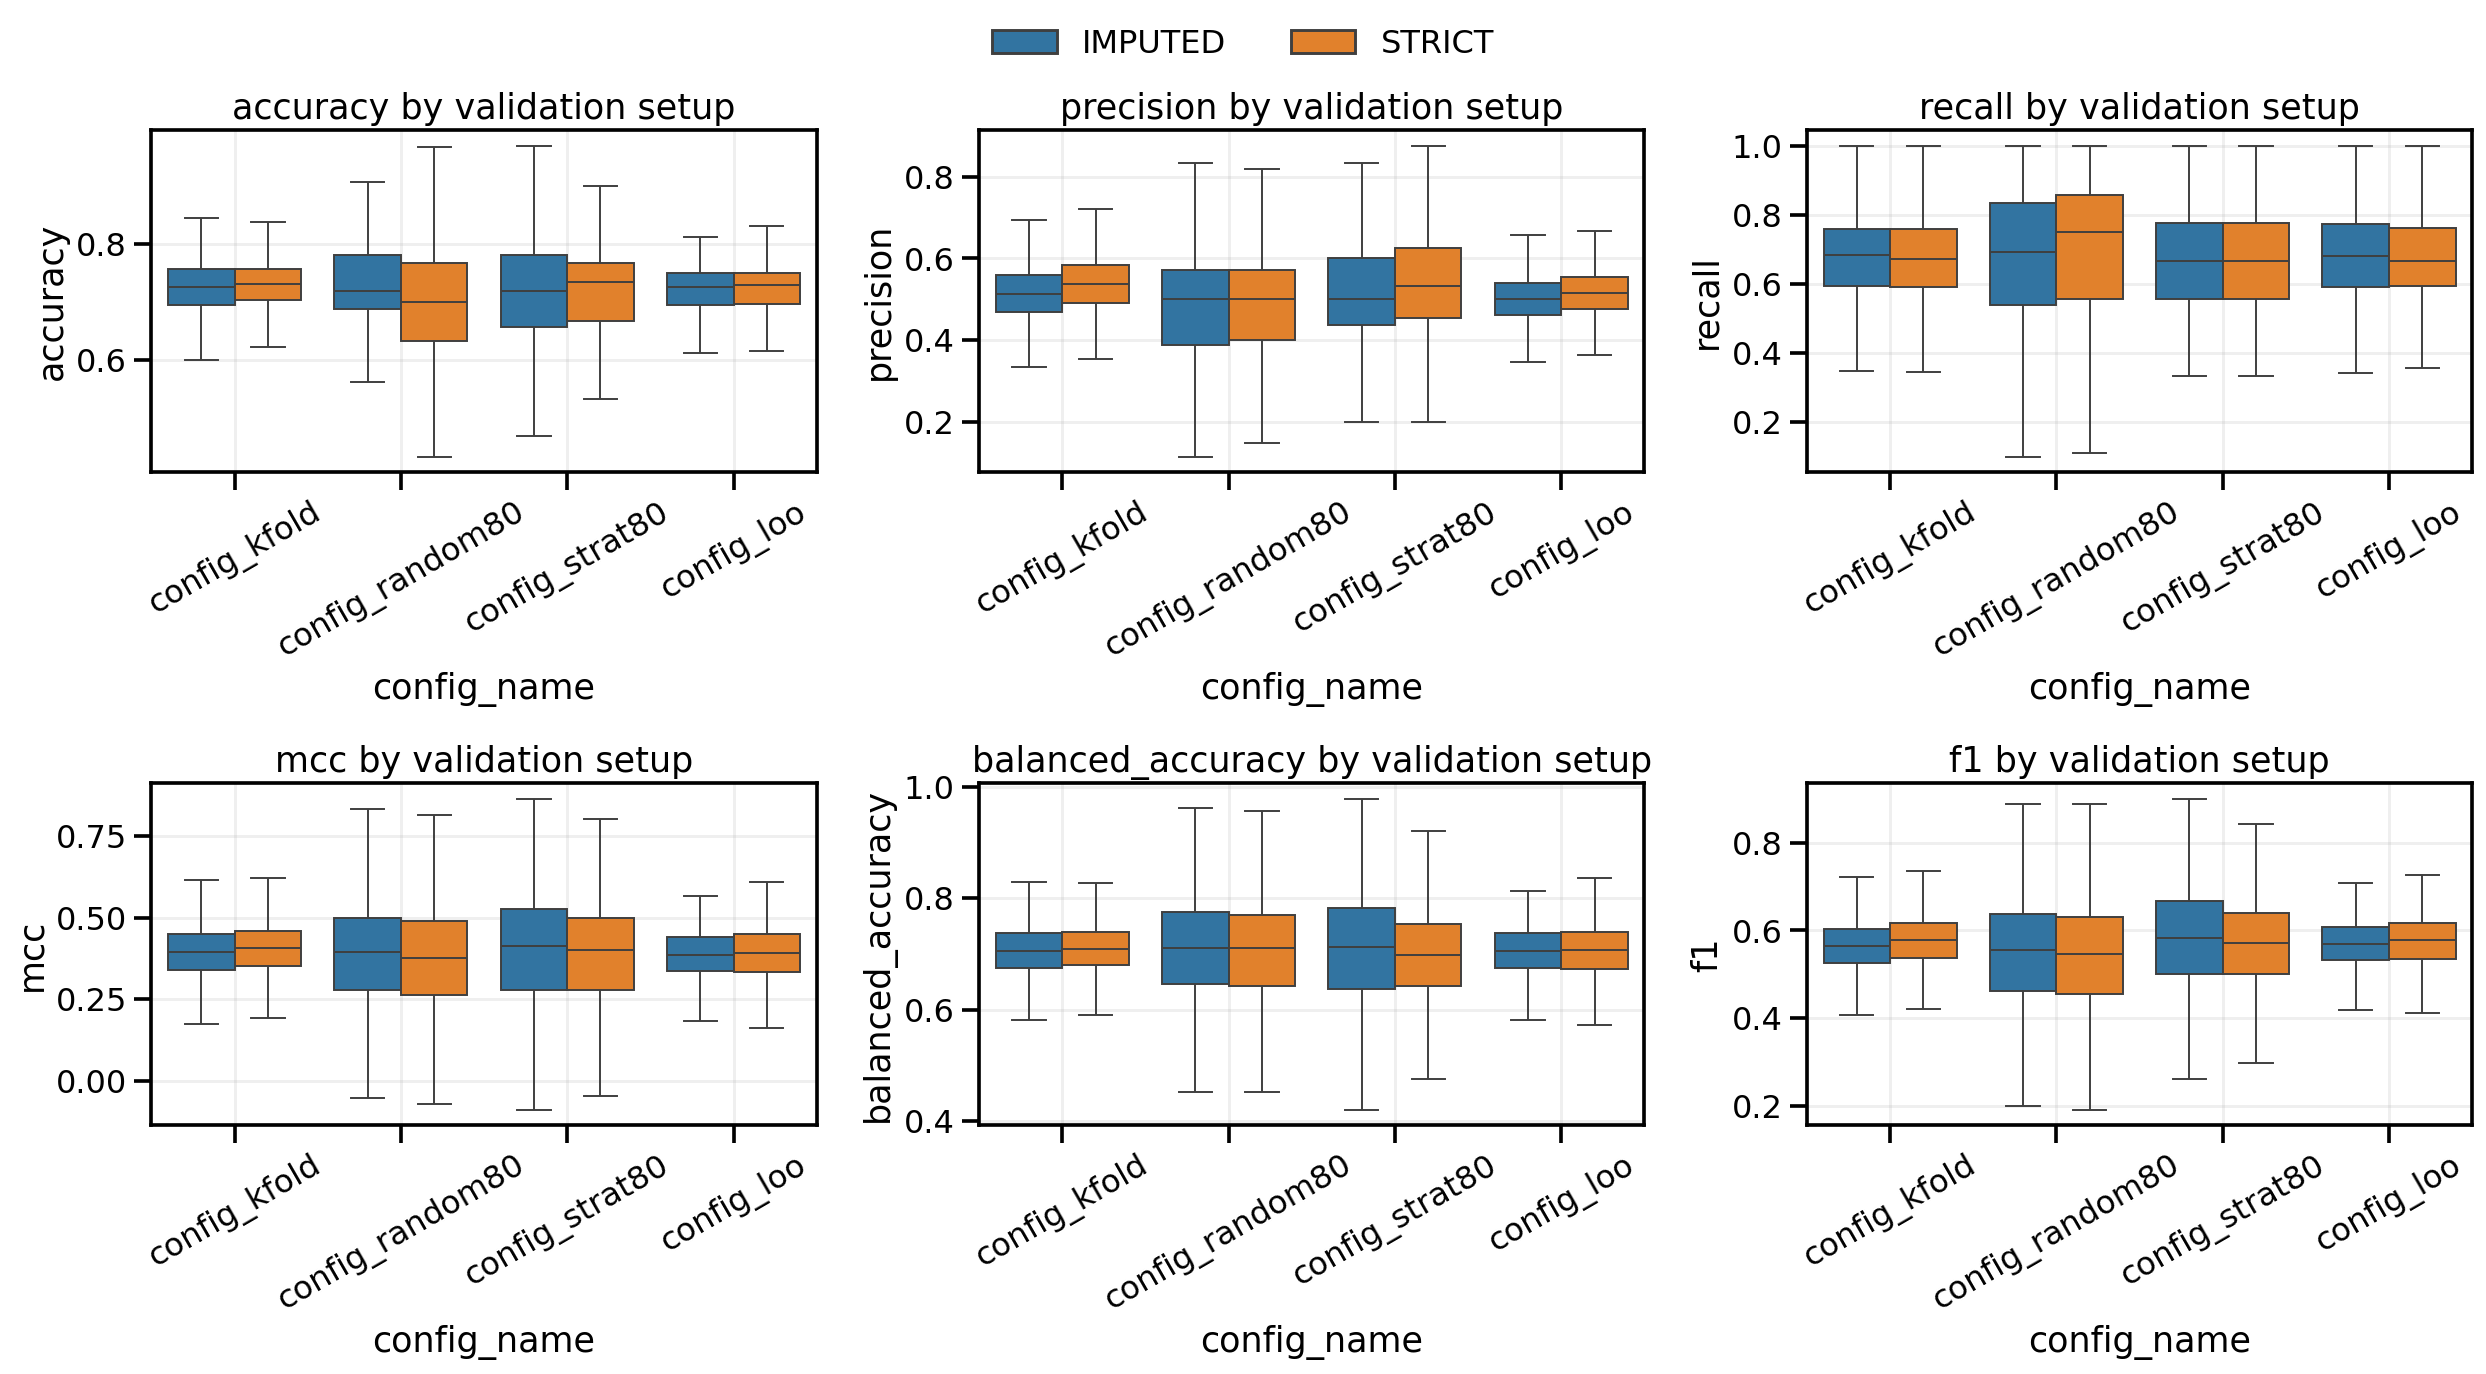

In [ ]:
metric_coverage = (
    results_seed_level
    .groupby("config_name")[METRIC_COLUMNS]
    .agg(lambda s: s.notna().sum())
)

metric_coverage_pct = (
    results_seed_level
    .groupby("config_name")[METRIC_COLUMNS]
    .agg(lambda s: s.notna().mean())
)

display(metric_coverage)
display(metric_coverage_pct)

comparison_metrics = ["accuracy", "precision", "recall", "mcc", "balanced_accuracy", "f1"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
handles, labels = None, None
for ax, metric in zip(axes.ravel(), comparison_metrics):
    plot_df = results_seed_level.loc[results_seed_level[metric].notna()].copy()
    sns.boxplot(
        data=plot_df,
        x="config_name",
        y=metric,
        hue="dataset_variant",
        ax=ax,
        showfliers=False,
    )
    ax.set_title(f"{metric} by validation setup")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.2)
    handles, labels = ax.get_legend_handles_labels()
    if ax.legend_ is not None:
        ax.legend_.remove()

fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_figure(fig, "classical_metrics_by_validation_setup.png")
plt.show()

In [ ]:
metric_overview = (
    results_seed_level
    .groupby(["dataset_variant", "config_name"], as_index=False)
    .agg(
        n_config_seed_runs=("combo_id", "count"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        brier_mean=("brier", "mean"),
        brier_std=("brier", "std"),
    )
    .sort_values(["dataset_variant", "config_name"])
)

metric_overview

,dataset_variant,config_name,n_config_seed_runs,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std
0,IMPUTED,config_kfold,452604,0.720847,0.051272,0.513445,0.082434,0.662374,0.146464,0.554836,0.084249,0.702983,0.051593,0.389174,0.091018,0.773315,0.051651,0.607142,0.074572,0.202850,0.033600
1,IMPUTED,config_loo,19716,0.719208,0.052531,0.504732,0.071072,0.665859,0.145532,0.560436,0.079731,0.702650,0.054488,0.382381,0.092047,NaN,NaN,NaN,NaN,NaN,NaN
2,IMPUTED,config_random80,255860,0.728123,0.086256,0.487681,0.156191,0.669849,0.214758,0.540620,0.140515,0.710076,0.096415,0.387684,0.171309,0.786006,0.095956,0.553056,0.136586,0.198804,0.051337
3,IMPUTED,config_strat80,255860,0.725174,0.097513,0.534696,0.160948,0.679279,0.201020,0.577377,0.139013,0.711206,0.098534,0.408317,0.188990,0.788538,0.111377,0.631210,0.164948,0.197844,0.061899
4,STRICT,config_kfold,491548,0.725240,0.049819,0.534393,0.087956,0.659336,0.145459,0.566588,0.089454,0.705311,0.053182,0.399697,0.095662,0.777617,0.057494,0.628295,0.079453,0.199702,0.032864
5,STRICT,config_loo,20073,0.721240,0.048597,0.518508,0.073231,0.657171,0.149330,0.565267,0.088193,0.701850,0.054812,0.385645,0.089783,NaN,NaN,NaN,NaN,NaN,NaN
6,STRICT,config_random80,249067,0.704782,0.103442,0.483466,0.162597,0.690034,0.203434,0.541320,0.139511,0.704515,0.093888,0.377927,0.174805,0.783380,0.099638,0.587032,0.157732,0.210371,0.066665
7,STRICT,config_strat80,255860,0.714717,0.081376,0.545170,0.148304,0.637360,0.197216,0.564241,0.123301,0.692615,0.082120,0.382528,0.158484,0.773479,0.085997,0.621277,0.124959,0.204217,0.051196


## 3. Top configurations

The next step is to identify the configurations that consistently rise to the top. Because leave-one-out (LOO) does not support fold-level probabilistic metrics, the main ranking used for cross-strategy comparison is based on classical classification metrics that are available for all validation setups after LOO reconstruction. A secondary probabilistic ranking can be developed later for non-LOO configurations only.

In [ ]:
config_group_cols = [
    "dataset_variant",
    "config_name",
    "val_strategy",
    "threshold",
    "model_key",
    "model_class",
    "model_params",
    "imputer",
    "scaler",
    "pca",
    "pca_params",
    "resampling",
    "resampling_params",
]

results_config_level = (
    results_seed_level
    .groupby(config_group_cols, dropna=False, as_index=False)
    .agg(
        n_seed_runs=("seed", "nunique"),
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        brier_mean=("brier", "mean"),
        brier_std=("brier", "std"),
        mean_n_eval_units=("n_evaluation_units", "mean"),
    )
)

for metric in ["accuracy", "precision", "recall", "f1", "balanced_accuracy", "mcc"]:
    results_config_level[f"rank_{metric}"] = results_config_level[f"{metric}_mean"].rank(
        ascending=False,
        method="dense",
    )

results_config_level["classical_composite_rank"] = (
    results_config_level["rank_accuracy"]
    + results_config_level["rank_precision"]
    + results_config_level["rank_recall"]
    + results_config_level["rank_f1"]
    + results_config_level["rank_balanced_accuracy"]
    + results_config_level["rank_mcc"]
)

top_configs = (
    results_config_level
    .sort_values(
        ["classical_composite_rank", "mcc_mean", "balanced_accuracy_mean", "f1_mean"],
        ascending=[True, False, False, False],
    )
    .reset_index(drop=True)
)

top_configs.head(20)

,dataset_variant,config_name,val_strategy,threshold,model_key,model_class,model_params,imputer,scaler,pca,pca_params,resampling,resampling_params,n_seed_runs,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,brier_mean,brier_std,mean_n_eval_units,rank_accuracy,rank_precision,rank_recall,rank_f1,rank_balanced_accuracy,rank_mcc,classical_composite_rank
0,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 1.0, ""class_weight"": ""balanced""}",median,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.812500,0.094327,0.636663,0.155001,0.911111,0.136586,0.739369,0.123893,0.842512,0.087564,0.639318,0.175664,0.882126,0.096274,0.791349,0.148573,0.156630,0.072981,1.0,11.0,2333.0,196.0,5.0,1.0,1.0,2547.0
1,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 1.0, ""class_weight"": ""balanced""}",none,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.812500,0.094327,0.636663,0.155001,0.911111,0.136586,0.739369,0.123893,0.842512,0.087564,0.639318,0.175664,0.882126,0.096274,0.791349,0.148573,0.156630,0.072981,1.0,11.0,2333.0,196.0,5.0,1.0,1.0,2547.0
2,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 0.1, ""class_weight"": ""balanced""}",median,robust,off,{},smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.831250,0.072469,0.679529,0.144761,0.822222,0.175291,0.731832,0.121853,0.828502,0.088163,0.630906,0.168971,0.877778,0.078594,0.779720,0.137395,0.141479,0.038366,1.0,2.0,1028.0,1999.0,6.0,9.0,2.0,3046.0
3,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 0.1, ""class_weight"": ""balanced""}",none,robust,off,{},smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.831250,0.072469,0.679529,0.144761,0.822222,0.175291,0.731832,0.121853,0.828502,0.088163,0.630906,0.168971,0.877778,0.078594,0.779720,0.137395,0.141479,0.038366,1.0,2.0,1028.0,1999.0,6.0,9.0,2.0,3046.0
4,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 1.0, ""class_weight"": ""balanced""}",median,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.803125,0.104219,0.624127,0.164876,0.900000,0.142965,0.727938,0.134661,0.832609,0.104670,0.618587,0.206039,0.881643,0.098301,0.789063,0.171911,0.152990,0.074567,1.0,20.0,3138.0,261.0,7.0,4.0,4.0,3434.0
5,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 1.0, ""class_weight"": ""balanced""}",none,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.803125,0.104219,0.624127,0.164876,0.900000,0.142965,0.727938,0.134661,0.832609,0.104670,0.618587,0.206039,0.881643,0.098301,0.789063,0.171911,0.152990,0.074567,1.0,20.0,3138.0,261.0,7.0,4.0,4.0,3434.0
6,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 0.1, ""class_weight"": ""balanced""}",median,robust,on,"{""n_components"": 0.99, ""svd_solver"": ""full"", ""...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,0.877295,0.078533,0.777549,0.137233,0.142206,0.037966,1.0,4.0,1218.0,2420.0,11.0,13.0,6.0,3672.0
7,IMPUTED,config_strat80,stratified_split_80_20,0.5,SVC_linear,SVC,"{""C"": 0.1, ""class_weight"": ""balanced""}",median,robust,on,"{""n_components"": 9, ""svd_solver"": ""full"", ""whi...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,0.877295,0.078533,0.777549,0.13723

In [ ]:
display_columns = [
    "dataset_variant",
    "config_name",
    "model_key",
    "imputer",
    "scaler",
    "pca",
    "pca_params",
    "resampling",
    "resampling_params",
    "n_seed_runs",
    "accuracy_mean",
    "accuracy_std",
    "precision_mean",
    "precision_std",
    "recall_mean",
    "recall_std",
    "f1_mean",
    "f1_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "mcc_mean",
    "mcc_std",
    "classical_composite_rank",
]

top_configs.loc[:, display_columns].head(20)

,dataset_variant,config_name,model_key,imputer,scaler,pca,pca_params,resampling,resampling_params,n_seed_runs,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,classical_composite_rank
0,IMPUTED,config_strat80,SVC_linear,median,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.812500,0.094327,0.636663,0.155001,0.911111,0.136586,0.739369,0.123893,0.842512,0.087564,0.639318,0.175664,2547.0
1,IMPUTED,config_strat80,SVC_linear,none,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.812500,0.094327,0.636663,0.155001,0.911111,0.136586,0.739369,0.123893,0.842512,0.087564,0.639318,0.175664,2547.0
2,IMPUTED,config_strat80,SVC_linear,median,robust,off,{},smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.831250,0.072469,0.679529,0.144761,0.822222,0.175291,0.731832,0.121853,0.828502,0.088163,0.630906,0.168971,3046.0
3,IMPUTED,config_strat80,SVC_linear,none,robust,off,{},smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.831250,0.072469,0.679529,0.144761,0.822222,0.175291,0.731832,0.121853,0.828502,0.088163,0.630906,0.168971,3046.0
4,IMPUTED,config_strat80,SVC_linear,median,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.803125,0.104219,0.624127,0.164876,0.900000,0.142965,0.727938,0.134661,0.832609,0.104670,0.618587,0.206039,3434.0
5,IMPUTED,config_strat80,SVC_linear,none,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smoteenn,"{""sampling_strategy"": 1.0, ""smote_k_neighbors""...",10,0.803125,0.104219,0.624127,0.164876,0.900000,0.142965,0.727938,0.134661,0.832609,0.104670,0.618587,0.206039,3434.0
6,IMPUTED,config_strat80,SVC_linear,median,robust,on,"{""n_components"": 0.99, ""svd_solver"": ""full"", ""...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,3672.0
7,IMPUTED,config_strat80,SVC_linear,median,robust,on,"{""n_components"": 9, ""svd_solver"": ""full"", ""whi...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,3672.0
8,IMPUTED,config_strat80,SVC_linear,none,robust,on,"{""n_components"": 0.99, ""svd_solver"": ""full"", ""...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,3672.0
9,IMPUTED,config_strat80,SVC_linear,none,robust,on,"{""n_components"": 9, ""svd_solver"": ""full"", ""whi...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.828125,0.071032,0.669708,0.132936,0.811111,0.166048,0.724985,0.122328,0.822947,0.088626,0.617686,0.169193,3672.0


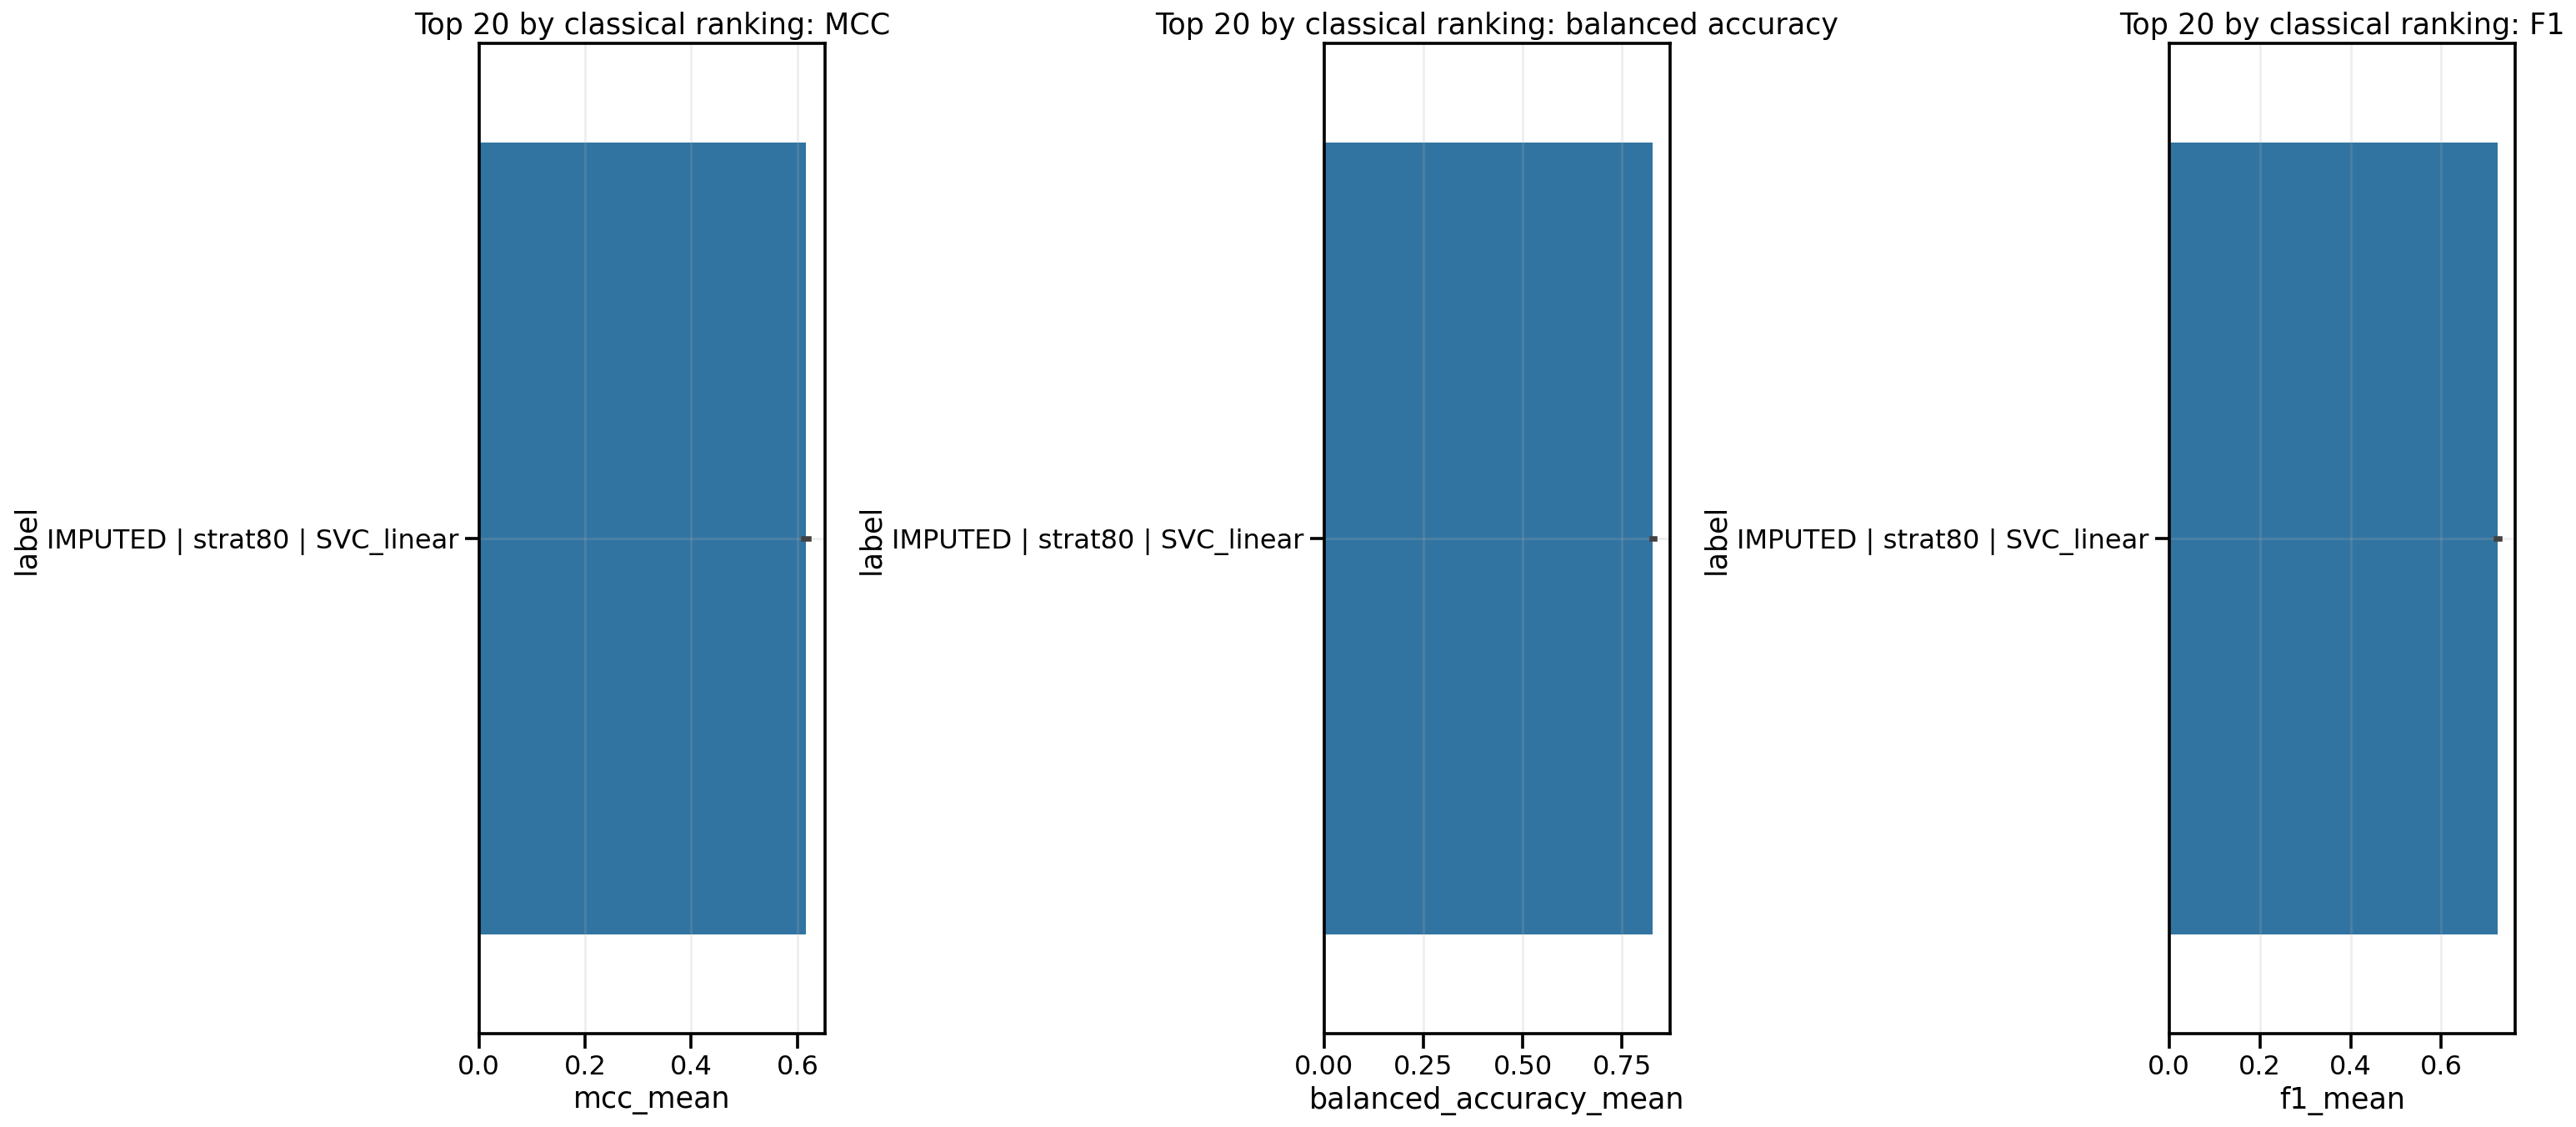

In [ ]:
top20 = top_configs.head(20).copy()
top20["label"] = (
    top20["dataset_variant"]
    + " | "
    + top20["config_name"].str.replace("config_", "", regex=False)
    + " | "
    + top20["model_key"]
)

fig, axes = plt.subplots(1, 3, figsize=(22, 10))

sns.barplot(data=top20.sort_values("mcc_mean", ascending=False), y="label", x="mcc_mean", ax=axes[0])
axes[0].set_title("Top 20 by classical ranking: MCC")
axes[0].grid(alpha=0.2)

sns.barplot(data=top20.sort_values("balanced_accuracy_mean", ascending=False), y="label", x="balanced_accuracy_mean", ax=axes[1])
axes[1].set_title("Top 20 by classical ranking: balanced accuracy")
axes[1].grid(alpha=0.2)

sns.barplot(data=top20.sort_values("f1_mean", ascending=False), y="label", x="f1_mean", ax=axes[2])
axes[2].set_title("Top 20 by classical ranking: F1")
axes[2].grid(alpha=0.2)

plt.tight_layout()
save_figure(fig, "top20_classical_ranking.png")
plt.show()

## 4. Stability across seeds

High mean performance is not sufficient if a configuration is unstable. Because the cross-strategy comparison now includes LOO through reconstructed classical metrics, the main stability analysis in this overview also relies on the same family of metrics. Probabilistic metrics can still be examined later for non-LOO settings, but the central comparison here is intentionally based on metrics available for every validation strategy.

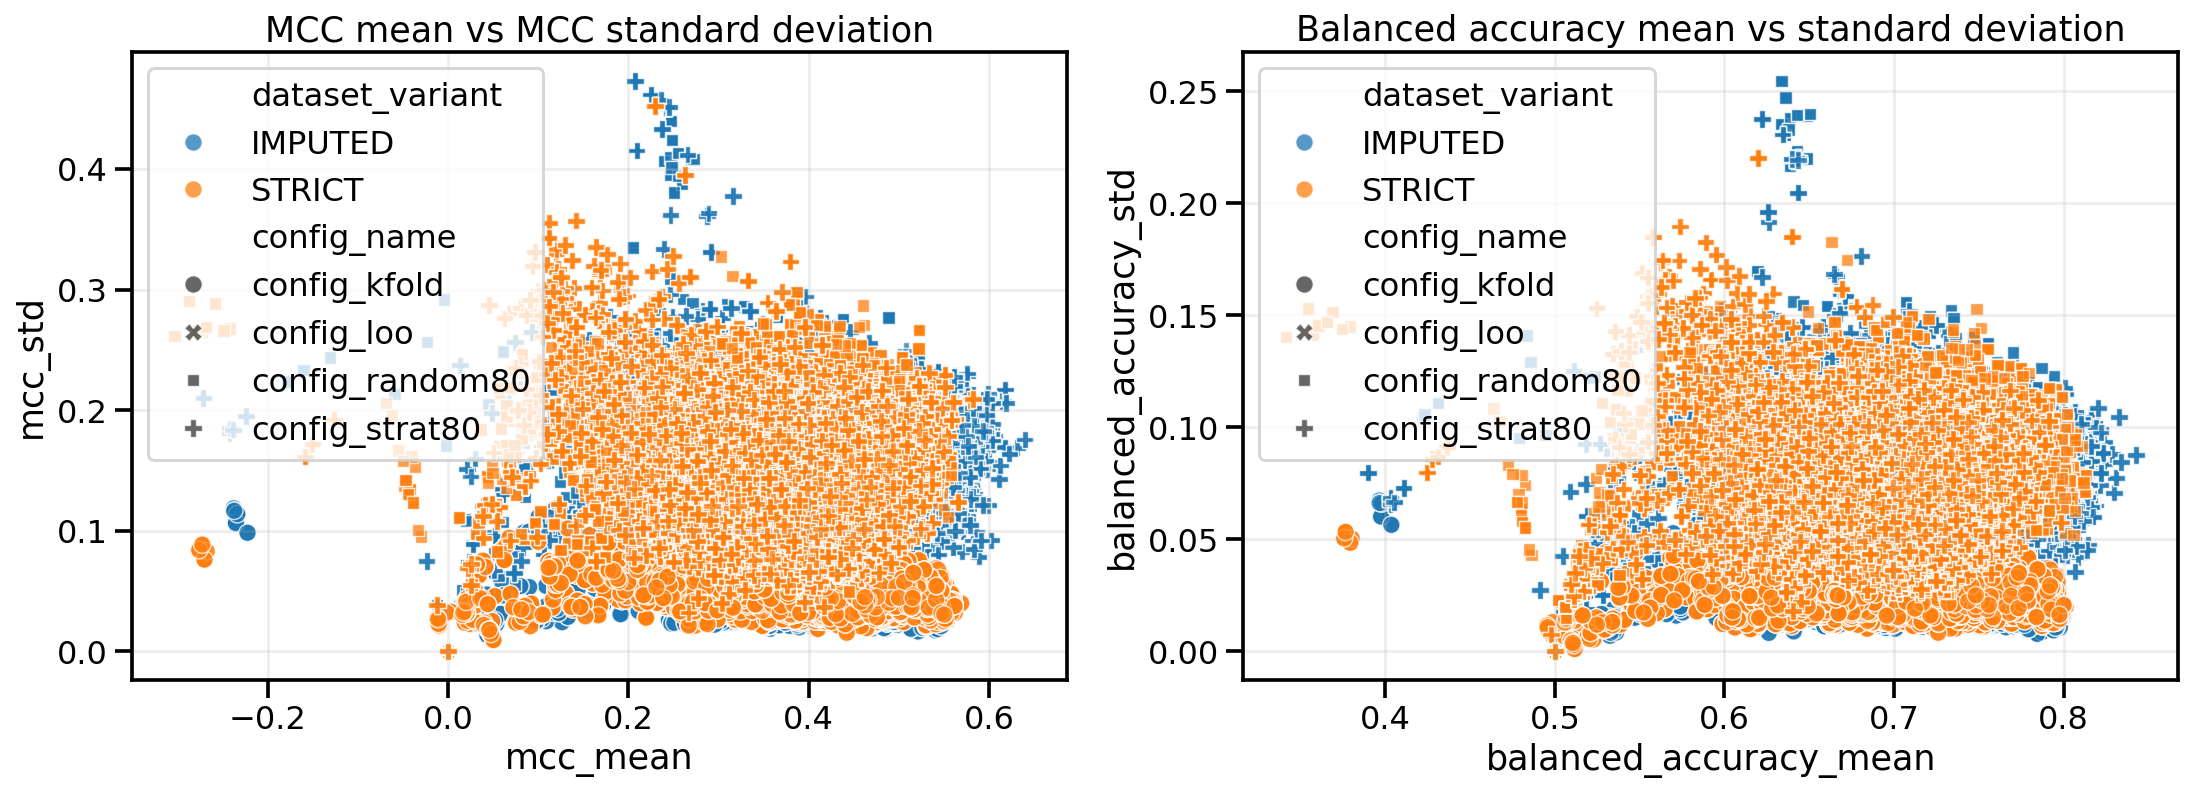

In [ ]:
stability_df = results_config_level.copy()
stability_df["performance_instability_ratio"] = stability_df["mcc_std"] / stability_df["mcc_mean"].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=stability_df,
    x="mcc_mean",
    y="mcc_std",
    hue="dataset_variant",
    style="config_name",
    alpha=0.75,
    ax=axes[0],
)
axes[0].set_title("MCC mean vs MCC standard deviation")
axes[0].grid(alpha=0.2)

sns.scatterplot(
    data=stability_df,
    x="balanced_accuracy_mean",
    y="balanced_accuracy_std",
    hue="dataset_variant",
    style="config_name",
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("Balanced accuracy mean vs standard deviation")
axes[1].grid(alpha=0.2)

plt.tight_layout()
save_figure(fig, "stability_classical_metrics.png")
plt.show()

In [ ]:
most_stable_high_perf = (
    stability_df
    .query("mcc_mean >= mcc_mean.quantile(0.90)")
    .sort_values(
        ["mcc_std", "balanced_accuracy_std", "f1_std", "mcc_mean"],
        ascending=[True, True, True, False],
    )
)

most_stable_high_perf.loc[:, display_columns].head(20)

,dataset_variant,config_name,model_key,imputer,scaler,pca,pca_params,resampling,resampling_params,n_seed_runs,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,mcc_mean,mcc_std,classical_composite_rank
11198,IMPUTED,config_kfold,LogisticRegression,median,standard,on,"{""n_components"": 0.9, ""svd_solver"": ""full"", ""w...",none,{},10,0.755625,0.009704,0.547216,0.015138,0.847389,0.018461,0.655823,0.011409,0.784341,0.007831,0.521089,0.016510,24759.0
11253,IMPUTED,config_kfold,LogisticRegression,median,standard,on,"{""n_components"": 7, ""svd_solver"": ""full"", ""whi...",none,{},10,0.755625,0.009704,0.547216,0.015138,0.847389,0.018461,0.655823,0.011409,0.784341,0.007831,0.521089,0.016510,24759.0
11473,IMPUTED,config_kfold,LogisticRegression,none,standard,on,"{""n_components"": 0.9, ""svd_solver"": ""full"", ""w...",none,{},10,0.755625,0.009704,0.547216,0.015138,0.847389,0.018461,0.655823,0.011409,0.784341,0.007831,0.521089,0.016510,24759.0
11528,IMPUTED,config_kfold,LogisticRegression,none,standard,on,"{""n_components"": 7, ""svd_solver"": ""full"", ""whi...",none,{},10,0.755625,0.009704,0.547216,0.015138,0.847389,0.018461,0.655823,0.011409,0.784341,0.007831,0.521089,0.016510,24759.0
11243,IMPUTED,config_kfold,LogisticRegression,median,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.765625,0.008954,0.562166,0.014039,0.855611,0.016000,0.667716,0.012254,0.793873,0.009986,0.540558,0.017480,17133.0
11518,IMPUTED,config_kfold,LogisticRegression,none,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",smote,"{""k_neighbors"": 3, ""sampling_strategy"": 0.75}",10,0.765625,0.008954,0.562166,0.014039,0.855611,0.016000,0.667716,0.012254,0.793873,0.009986,0.540558,0.017480,17133.0
12342,IMPUTED,config_kfold,LogisticRegression,median,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",none,{},10,0.773125,0.009955,0.572282,0.017295,0.839306,0.015383,0.670415,0.012845,0.793886,0.009397,0.542735,0.018468,14612.0
12617,IMPUTED,config_kfold,LogisticRegression,none,standard,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",none,{},10,0.773125,0.009955,0.572282,0.017295,0.839306,0.015383,0.670415,0.012845,0.793886,0.009397,0.542735,0.018468,14612.0
24650,IMPUTED,config_kfold,SVC_linear,median,robust,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",undersample,"{""replacement"": false, ""sampling_strategy"": 1.0}",10,0.756696,0.011090,0.548826,0.012689,0.828413,0.017413,0.648725,0.011360,0.779294,0.009874,0.513361,0.018738,26678.0
24925,IMPUTED,config_kfold,SVC_linear,none,robust,on,"{""n_components"": 5, ""svd_solver"": ""full"", ""whi...",undersample,"{""replacement"": false, ""sampling_strategy"": 1.0}",10,0.756696,0.011090,0.548826,0.012689,0.828413,0.017413,0.648725,0.011360,0.779294,0.009874,0.513361,0.018738,26678.0


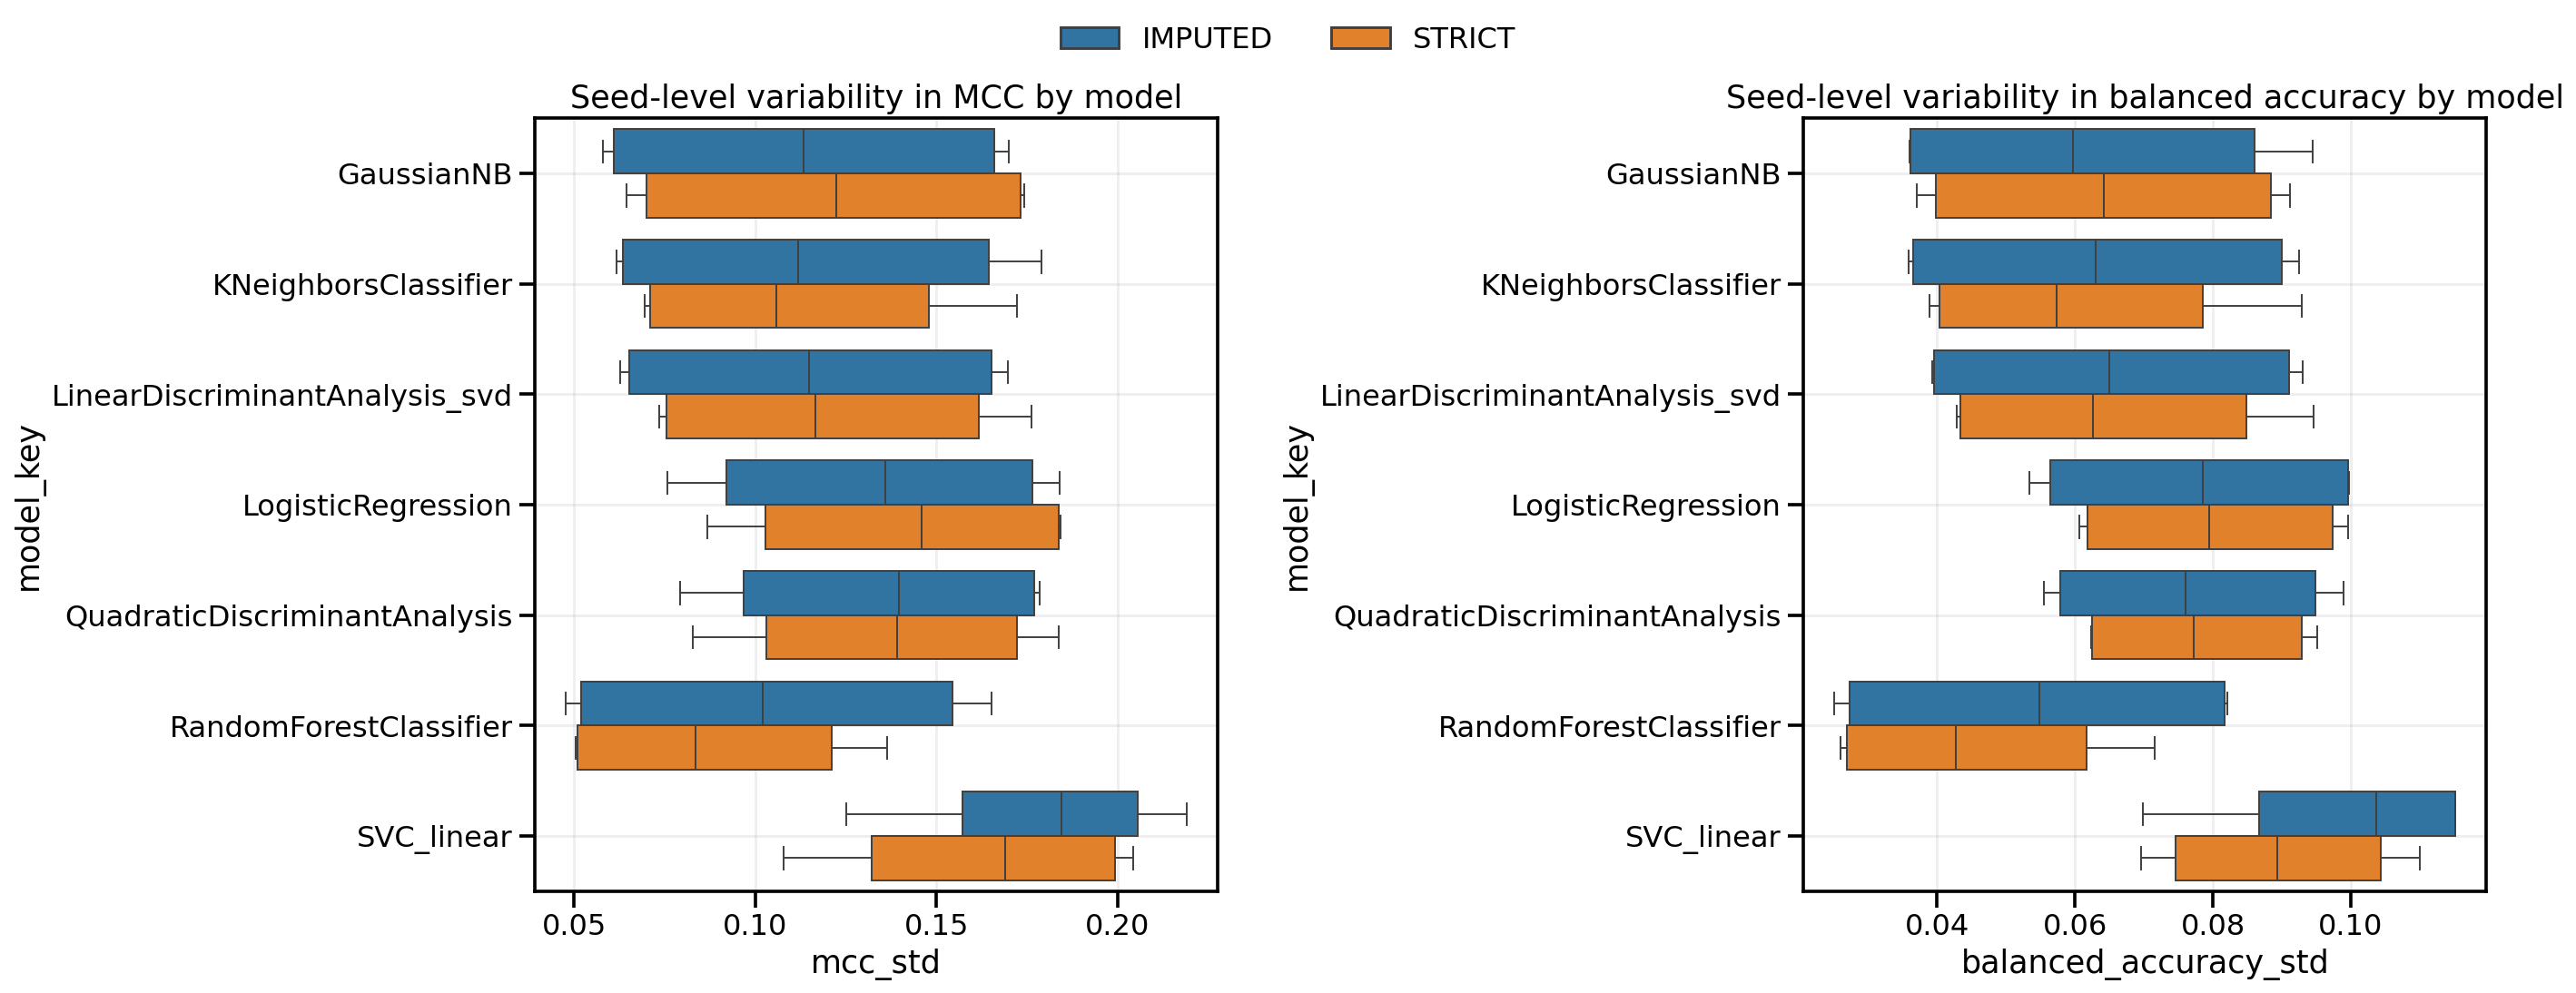

In [ ]:
seed_variability_by_model = (
    results_seed_level
    .groupby(["dataset_variant", "config_name", "model_key"], as_index=False)
    .agg(
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        n_rows=("combo_id", "count"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.boxplot(
    data=seed_variability_by_model,
    y="model_key",
    x="mcc_std",
    hue="dataset_variant",
    ax=axes[0],
    showfliers=False,
)
axes[0].set_title("Seed-level variability in MCC by model")
axes[0].grid(alpha=0.2)

sns.boxplot(
    data=seed_variability_by_model,
    y="model_key",
    x="balanced_accuracy_std",
    hue="dataset_variant",
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title("Seed-level variability in balanced accuracy by model")
axes[1].grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_figure(fig, "seed_variability_by_model_classical.png")
plt.show()

## 5. Quick takeaways for the next notebooks

This overview notebook should leave us with an initial sense of the performance landscape. At this stage, the most relevant outputs are the global distribution of metrics across validation settings and dataset variants, the shortlist of top-performing configurations under a fair classical-metric comparison, and the identification of configurations that combine good mean performance with low seed-to-seed instability.

The next notebooks can build on these exported tables to quantify factor effects, interaction patterns, and information gains across preprocessing and model choices. For non-LOO settings, probabilistic metrics can still be explored in parallel, but the core cross-validation comparison should remain anchored in the metrics that are available and interpretable across all validation strategies.

In [ ]:
results_seed_level.to_csv(ANALYSIS_DIR / "results_seed_level.csv", index=False)
results_config_level.to_csv(ANALYSIS_DIR / "results_config_level.csv", index=False)
run_summary.to_csv(ANALYSIS_DIR / "run_summary.csv", index=False)
metric_overview.to_csv(ANALYSIS_DIR / "metric_overview.csv", index=False)
metric_coverage.to_csv(ANALYSIS_DIR / "metric_coverage_counts.csv")
metric_coverage_pct.to_csv(ANALYSIS_DIR / "metric_coverage_fraction.csv")

print("Saved analysis tables to:", ANALYSIS_DIR)
print("Saved figures to:", FIGURES_DIR)
sorted(FIGURES_DIR.glob("*.png"))

Saved analysis tables to: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_tables
Saved figures to: /home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/01_performance_overview


[PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/01_performance_overview/classical_metrics_by_validation_setup.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/01_performance_overview/metric_distributions_seed_level.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/01_performance_overview/seed_variability_by_model_classical.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/01_performance_overview/stability_classical_metrics.png'),
 PosixPath('/home/david/Desktop/colabs/serra_ramon/hypercholesterolemia_classifiers/notebooks/modelling/analysis_figures/01_performance_overview/top20_classical_ranking.png')]